In [1]:
# import standard tools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# stop pandas from hiding columns
pd.set_option('display.width', 120)

In [8]:
# load the scaled files member 3 saved in the data folder
train_df = pd.read_csv('../data/train_scaled.csv')
test_df = pd.read_csv('../data/test_scaled.csv')

# separate features from the target
y_train = train_df['Bankrupt?']
X_train = train_df.drop(columns=['Bankrupt?'])

y_test = test_df['Bankrupt?']
X_test = test_df.drop(columns=['Bankrupt?'])

print("starting train shape:", X_train.shape)

starting train shape: (5455, 95)


In [9]:
# find cols where 99% or more of the data is exactly the same
quasi_constant_cols = []
for col in X_train.columns:
    # get the percentage of the most common value
    top_freq = X_train[col].value_counts(normalize=True).iloc[0]
    if top_freq >= 0.99:
        quasi_constant_cols.append(col)

# drop them from both train and test
X_train = X_train.drop(columns=quasi_constant_cols)
X_test = X_test.drop(columns=quasi_constant_cols)

print("dropped (quasi-constant):", quasi_constant_cols)
print("shape after drop:", X_train.shape)

dropped (quasi-constant): ['Liability-Assets Flag', 'Net Income Flag']
shape after drop: (5455, 93)


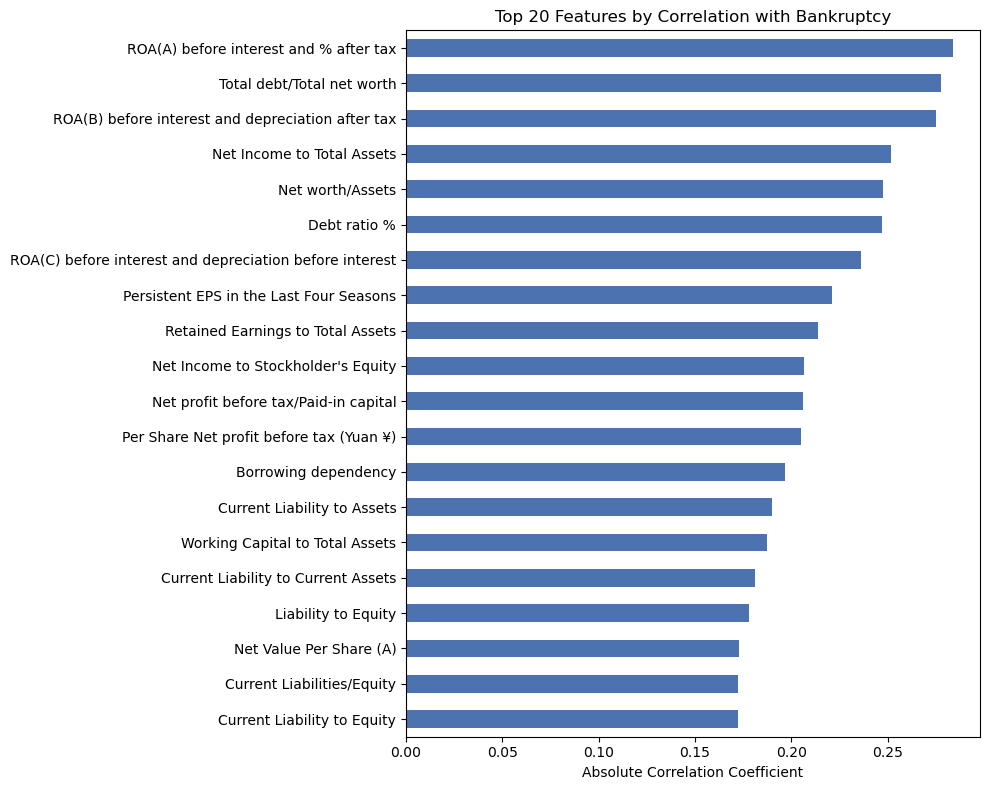

dropped 30 features with near-zero target correlation.
shape after target filter: (5455, 63)


In [10]:
# Reattach target temporarily to calculate correlations on the current feature set
train_reduced = X_train.copy()
train_reduced['Bankrupt?'] = y_train

# calc correlation of all remaining features against the target
target_corr = train_reduced.corr()['Bankrupt?'].drop('Bankrupt?')

# get absolute values so we can sort them properly
target_corr_abs = target_corr.abs().sort_values(ascending=False)

# plot the top 20 most important features
plt.figure(figsize=(10, 8))
target_corr_abs.head(20).sort_values().plot(kind='barh', color='#4C72B0')
plt.title('Top 20 Features by Correlation with Bankruptcy')
plt.xlabel('Absolute Correlation Coefficient')
plt.tight_layout()

# save visual
plt.savefig('../results/eda_visualizations/member4_target_correlation.png', dpi=110)
plt.show()

# drop features that have less than 0.02 correlation with target
irrelevant_cols = target_corr_abs[target_corr_abs < 0.02].index.tolist()
X_train = X_train.drop(columns=irrelevant_cols)
X_test = X_test.drop(columns=irrelevant_cols)

print(f"dropped {len(irrelevant_cols)} features with near-zero target correlation.")
print("shape after target filter:", X_train.shape)

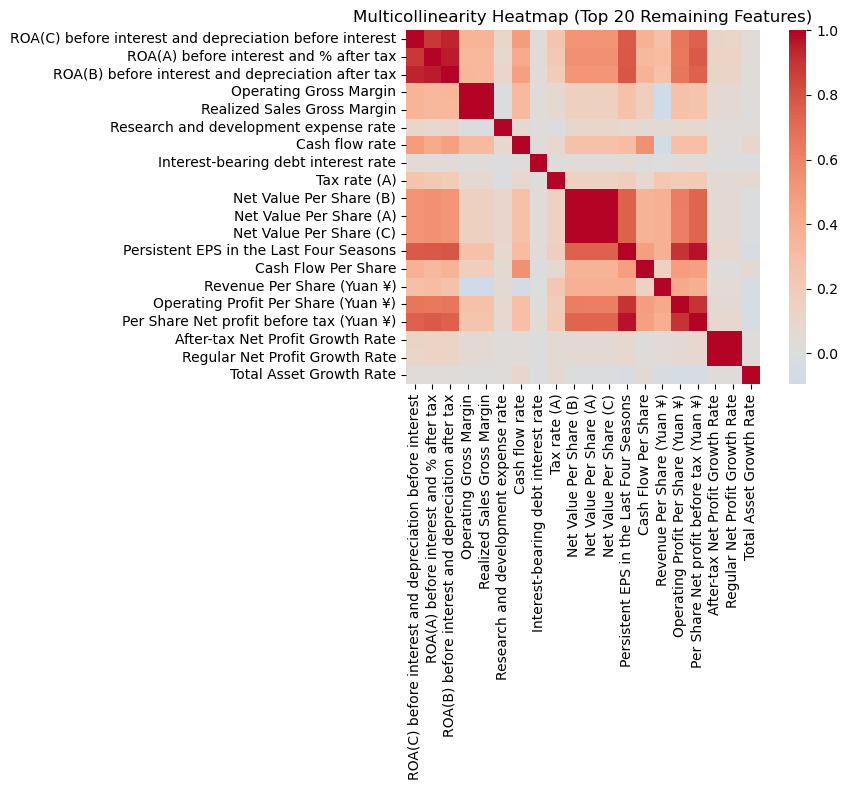

dropped 16 redundant features.
final train shape: (5455, 47)


In [6]:
# get top 20 remaining features for a clean heatmap
top_features = target_corr_abs.loc[X_train.columns].head(20).index.tolist()

# calc correlation matrix just for the remaining features
corr_matrix = X_train[top_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, square=True)
plt.title('Multicollinearity Heatmap (Top 20 Remaining Features)')
plt.tight_layout()

# save visual
plt.savefig('../results/eda_visualizations/member4_feature_heatmap.png', dpi=110)
plt.show()

# script to drop highly correlated feature pairs (>0.9)
corr_abs = X_train.corr().abs()
# grab just the upper triangle of the matrix to avoid checking duplicates
upper = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))

to_drop = set()
for col in upper.columns:
    # find features highly correlated with this column
    correlated_with = upper.index[upper[col] > 0.9].tolist()
    for other in correlated_with:
        if col in to_drop or other in to_drop:
            continue
        # logic: keep the one that correlates better with the target
        if target_corr_abs.get(col, 0) >= target_corr_abs.get(other, 0):
            to_drop.add(other)
        else:
            to_drop.add(col)

# drop redundant cols from train and test sets
X_train = X_train.drop(columns=list(to_drop))
X_test = X_test.drop(columns=list(to_drop))

print(f"dropped {len(to_drop)} redundant features.")
print("final train shape:", X_train.shape)

In [7]:
# reattach the target columns before saving
train_final_df = X_train.copy()
train_final_df['Bankrupt?'] = y_train.values

test_final_df = X_test.copy()
test_final_df['Bankrupt?'] = y_test.values

# save intermediate files to data folder for member 5 (PCA)
train_final_df.to_csv('../data/train_selected.csv', index=False)
test_final_df.to_csv('../data/test_selected.csv', index=False)

print("saved train_selected.csv and test_selected.csv")

saved train_selected.csv and test_selected.csv
